In [ ]:
# ============================================================
# Task 4: Loan Default Risk with Business Cost Optimization
# ============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,roc_curve)
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

In [ ]:
# ============================================================
# 1. Load Dataset
# ============================================================

In [2]:
df = pd.read_csv("application_train.csv")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nTarget Distribution:")
print(df["TARGET"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))


First 5 Rows:
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                

In [ ]:
# ============================================================
# 2. Basic EDA
# ============================================================

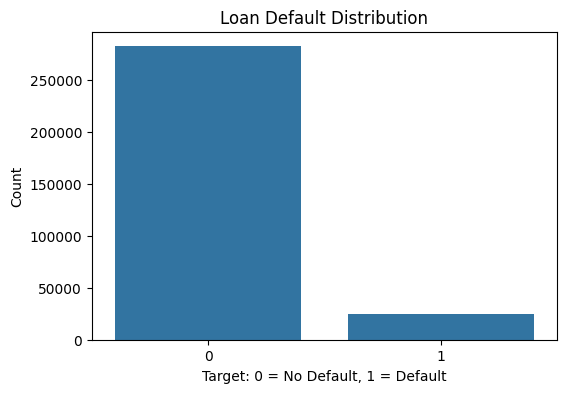


Target Percentage:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x="TARGET", data=df)
plt.title("Loan Default Distribution")
plt.xlabel("Target: 0 = No Default, 1 = Default")
plt.ylabel("Count")
plt.show()

target_counts = df["TARGET"].value_counts(normalize=True) * 100
print("\nTarget Percentage:")
print(target_counts)

In [ ]:
# ============================================================
# 3. Reduce Dataset for Faster Training
# ============================================================

In [4]:
# Using sample for faster execution
df_sample = df.sample(n=50000, random_state=42)

print("\nSample Shape:")
print(df_sample.shape)


Sample Shape:
(50000, 122)


In [ ]:
# ============================================================
# 4. Drop ID Column
# ============================================================

In [5]:
X = df_sample.drop("TARGET", axis=1)
y = df_sample["TARGET"]

In [ ]:
# ============================================================
# 6. Identify Numerical and Categorical Columns
# ============================================================

In [6]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nCategorical Columns:", len(categorical_cols))
print("Numerical Columns:", len(numerical_cols))


Categorical Columns: 16
Numerical Columns: 105


In [ ]:
# ============================================================
# 7. Handle Missing Values
# ============================================================

In [8]:
for col in numerical_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

In [ ]:
# ============================================================
# 8. Train-Test Split
# ============================================================

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# ============================================================
# 9. Logistic Regression Preprocessing
# ============================================================

In [10]:
X_lr = pd.get_dummies(X, drop_first=True)

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()

X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

In [ ]:
# ============================================================
# 10. Logistic Regression Model
# ============================================================


================ Logistic Regression Results ================
Accuracy: 0.6829
Precision: 0.15630447414294016
Recall: 0.6683229813664596
F1 Score: 0.25335530963032726
ROC-AUC: 0.7417629754221002


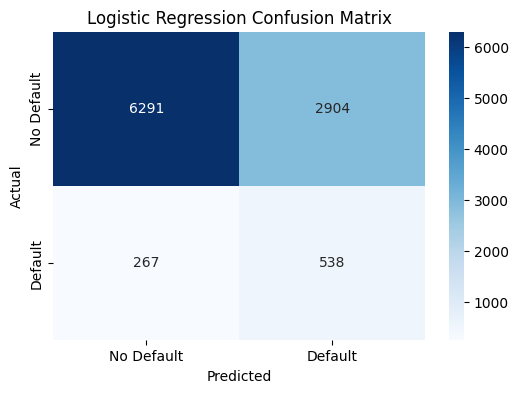

In [11]:
log_model = LogisticRegression(max_iter=1000,class_weight="balanced")

log_model.fit(X_train_lr_scaled, y_train_lr)

log_pred = log_model.predict(X_test_lr_scaled)
log_prob = log_model.predict_proba(X_test_lr_scaled)[:, 1]

print("\n================ Logistic Regression Results ================")
print("Accuracy:", accuracy_score(y_test_lr, log_pred))
print("Precision:", precision_score(y_test_lr, log_pred))
print("Recall:", recall_score(y_test_lr, log_pred))
print("F1 Score:", f1_score(y_test_lr, log_pred))
print("ROC-AUC:", roc_auc_score(y_test_lr, log_prob))

# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test_lr, log_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr,annot=True,fmt="d",cmap="Blues",xticklabels=["No Default", "Default"],yticklabels=["No Default", "Default"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ============================================================
# 11. CatBoost Model
# ============================================================

0:	test: 0.6755584	best: 0.6755584 (0)	total: 358ms	remaining: 1m 46s
100:	test: 0.7431850	best: 0.7432443 (97)	total: 24.1s	remaining: 47.5s
200:	test: 0.7463230	best: 0.7463955 (198)	total: 46.4s	remaining: 22.8s
299:	test: 0.7504798	best: 0.7507948 (297)	total: 1m 10s	remaining: 0us

bestTest = 0.7507947541
bestIteration = 297

Shrink model to first 298 iterations.

================ CatBoost Results ================
Accuracy: 0.7271
Precision: 0.17345553292600135
Recall: 0.6347826086956522
F1 Score: 0.2724606771527593
ROC-AUC: 0.7507947541027902


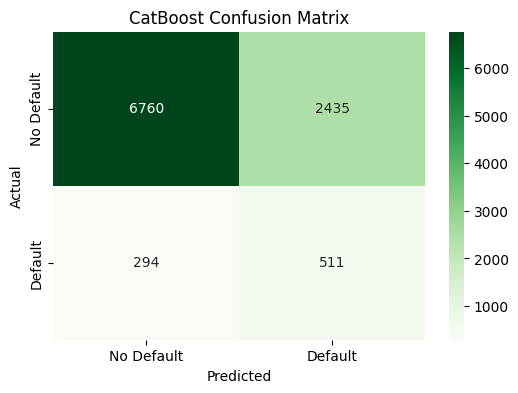

In [12]:
cat_features_indices = [X_train.columns.get_loc(col)for col in categorical_cols]

cat_model = CatBoostClassifier(iterations=300,learning_rate=0.05,depth=6,loss_function="Logloss",
eval_metric="AUC",random_seed=42,verbose=100,auto_class_weights="Balanced")

cat_model.fit(X_train,y_train,cat_features=cat_features_indices,eval_set=(X_test, y_test))

cat_pred = cat_model.predict(X_test)
cat_prob = cat_model.predict_proba(X_test)[:, 1]

print("\n================ CatBoost Results ================")
print("Accuracy:", accuracy_score(y_test, cat_pred))
print("Precision:", precision_score(y_test, cat_pred))
print("Recall:", recall_score(y_test, cat_pred))
print("F1 Score:", f1_score(y_test, cat_pred))
print("ROC-AUC:", roc_auc_score(y_test, cat_prob))

# Confusion Matrix - CatBoost
cm_cat = confusion_matrix(y_test, cat_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_cat,annot=True,fmt="d",cmap="Greens",xticklabels=["No Default", "Default"],yticklabels=["No Default", "Default"])
plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# ============================================================
# 12. ROC Curve Comparison
# ============================================================

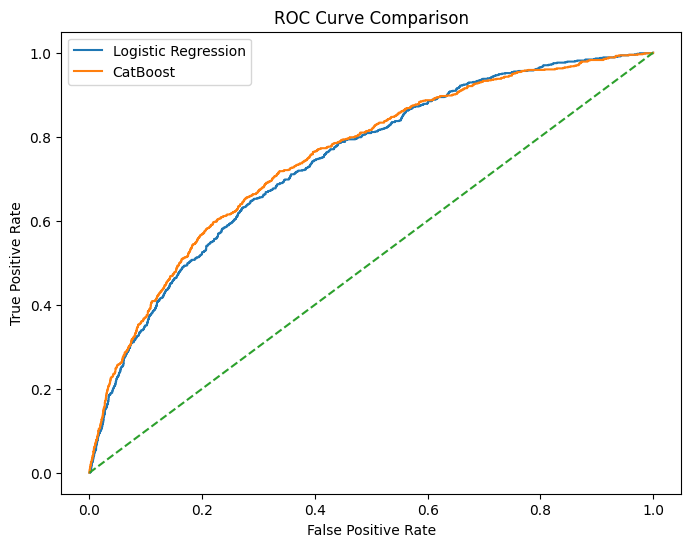

In [13]:
log_fpr, log_tpr, _ = roc_curve(y_test_lr, log_prob)
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_prob)

plt.figure(figsize=(8, 6))
plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(cat_fpr, cat_tpr, label="CatBoost")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# 13. Business Cost Optimization
# ============================================================


================ Business Cost Optimization ================
   Threshold  False Positives  False Negatives  Total Cost
0       0.10             8723                5        8773
1       0.11             8621                6        8681
2       0.12             8505                9        8595
3       0.13             8388               12        8508
4       0.14             8265               14        8405

Best Threshold:
Threshold             0.53
False Positives    2054.00
False Negatives     324.00
Total Cost         5294.00
Name: 43, dtype: float64


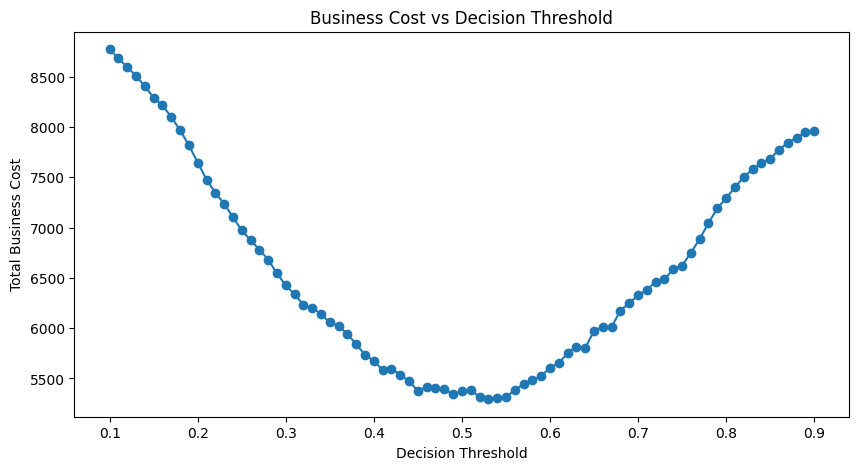

In [14]:
# Business assumption:
# False Positive = Rejecting a good customer
# False Negative = Approving a customer who defaults

FP_COST = 1
FN_COST = 10

thresholds = np.arange(0.1, 0.91, 0.01)

cost_results = []

for threshold in thresholds:
    threshold_pred = (cat_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, threshold_pred).ravel()

    total_cost = (fp * FP_COST) + (fn * FN_COST)

    cost_results.append({
        "Threshold": threshold,
        "False Positives": fp,
        "False Negatives": fn,
        "Total Cost": total_cost
    })

cost_df = pd.DataFrame(cost_results)

best_row = cost_df.loc[cost_df["Total Cost"].idxmin()]
best_threshold = best_row["Threshold"]

print("\n================ Business Cost Optimization ================")
print(cost_df.head())
print("\nBest Threshold:")
print(best_row)

plt.figure(figsize=(10, 5))
plt.plot(cost_df["Threshold"], cost_df["Total Cost"], marker="o")
plt.title("Business Cost vs Decision Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Business Cost")
plt.show()

In [ ]:
# ============================================================
# 14. Final Prediction Using Best Threshold
# ============================================================


================ Optimized CatBoost Results ================
Best Threshold: 0.5299999999999998
Accuracy: 0.7622
Precision: 0.18974358974358974
Recall: 0.5975155279503106
F1 Score: 0.2880239520958084
ROC-AUC: 0.7507947541027902


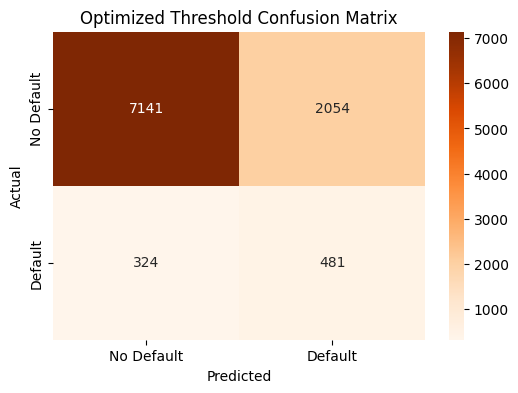

In [16]:
optimized_pred = (cat_prob >= best_threshold).astype(int)

print("\n================ Optimized CatBoost Results ================")
print("Best Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, optimized_pred))
print("Precision:", precision_score(y_test, optimized_pred))
print("Recall:", recall_score(y_test, optimized_pred))
print("F1 Score:", f1_score(y_test, optimized_pred))
print("ROC-AUC:", roc_auc_score(y_test, cat_prob))

cm_opt = confusion_matrix(y_test, optimized_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt,annot=True,fmt="d",cmap="Oranges",xticklabels=["No Default", "Default"],yticklabels=["No Default", "Default"])
plt.title("Optimized Threshold Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ============================================================
# 15. Feature Importance
# ============================================================


Top 15 Important Features:
                   Feature  Importance
41            EXT_SOURCE_2    9.473438
42            EXT_SOURCE_3    9.368927
40            EXT_SOURCE_1    5.719114
17           DAYS_EMPLOYED    4.504683
7               AMT_CREDIT    4.381445
16              DAYS_BIRTH    4.254892
94  DAYS_LAST_PHONE_CHANGE    3.785723
9          AMT_GOODS_PRICE    3.527638
8              AMT_ANNUITY    2.562446
19         DAYS_ID_PUBLISH    2.205489
12     NAME_EDUCATION_TYPE    2.007785
39       ORGANIZATION_TYPE    1.746578
11        NAME_INCOME_TYPE    1.676590
0               SK_ID_CURR    1.597402
27         OCCUPATION_TYPE    1.476268


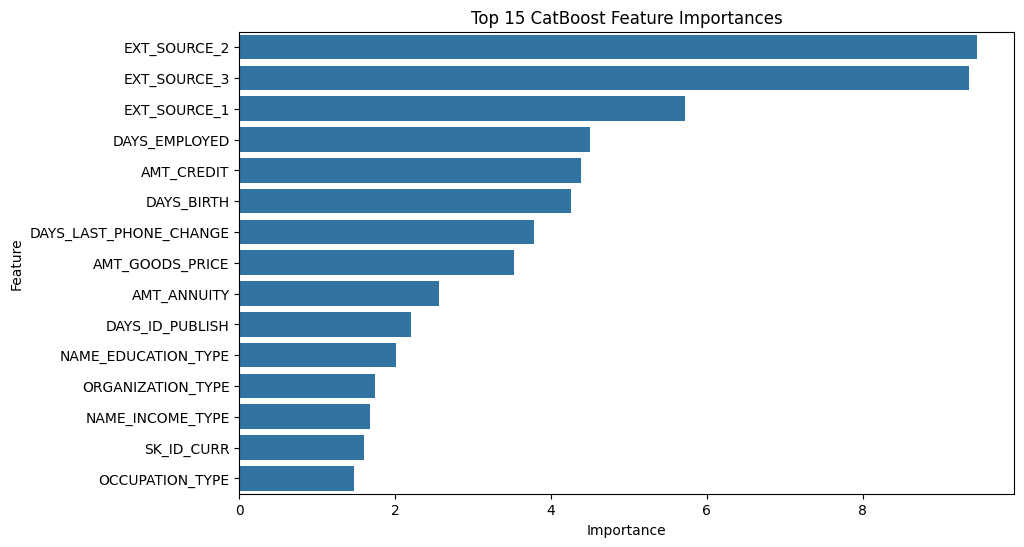

In [17]:
feature_importance = pd.DataFrame({"Feature": X_train.columns,"Importance": cat_model.get_feature_importance()})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False).head(15)

print("\nTop 15 Important Features:")
print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance",y="Feature",data=feature_importance)
plt.title("Top 15 CatBoost Feature Importances")
plt.show()

In [ ]:
# ============================================================
# 16. Final Conclusion
# ============================================================

In [18]:
print(f"Best Cost-Optimized Threshold: {best_threshold:.2f}")

Best Cost-Optimized Threshold: 0.53


In [ ]:
# This project successfully developed a loan default risk prediction model using the Home Credit Default Risk dataset. 
# Logistic Regression was used as a baseline model, while CatBoost achieved better overall performance. 
# Since the dataset was highly imbalanced, evaluation focused on Recall, F1 Score, ROC-AUC, and business cost optimization instead of accuracy alone.
# A cost-based threshold optimization approach was applied by assigning a higher cost to false negatives, as approving a customer who later defaults creates greater financial risk. 
# The best cost-optimized threshold was **0.52**, which minimized the total business cost. 
# Overall, this project shows how machine learning can support more risk-aware and cost-effective loan approval decisions.